# ODD + OOD Detection for Safe Autonomy
**Camera-based safety gate for autonomous driving**

- **Input**: Front camera frame
- **Output**: "Trust / Abstain" gate decision
- **ODD**: Daytime + Clear weather + Urban/Highway
- **OOD buckets**: Night, Rain, Fog/Snow

**Members**: Tharun Reddy Challabotla, HariChandana Srikurmum, Srija

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm
!pip install -q kagglehub

In [2]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Dataset Download (BDD100K Weather Classification via kagglehub)

Uses `kagglehub` — no `kaggle.json` file upload needed.  
On first run it will ask you to authenticate via browser (one-time). The dataset is cached in `~/.cache/kagglehub` and reused on subsequent runs.

In [3]:
import kagglehub

# Download latest version — authenticates via browser on first run
# Credentials are cached in ~/.cache/kagglehub after the first login
kaggle_path = kagglehub.dataset_download('marquis03/bdd100k-weather-classification')
print('Path to dataset files:', kaggle_path)

from pathlib import Path
BDD_RAW = Path(kaggle_path)

# kagglehub sometimes nests files under a version subfolder;
# find the directory that actually contains train/ and val/ folders
def find_dataset_root(base: Path) -> Path:
    if (base / 'train').exists() or (base / 'val').exists():
        return base
    for child in sorted(base.rglob('train')):
        if child.is_dir():
            return child.parent
    return base
BDD_RAW = find_dataset_root(BDD_RAW)
print(f'Dataset root: {BDD_RAW}')

# Show splits and weather folders
for split in ['train', 'val']:
    split_dir = BDD_RAW / split
    if split_dir.exists():
        folders = [f.name for f in sorted(split_dir.iterdir()) if f.is_dir()]
        print(f'  {split}: {folders}')

Using Colab cache for faster access to the 'bdd100k-weather-classification' dataset.
Path to dataset files: /kaggle/input/bdd100k-weather-classification
Dataset root: /kaggle/input/bdd100k-weather-classification
  train: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']
  val: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']


In [4]:
# Verify dataset structure
DATA_ROOT = BDD_RAW  # alias used throughout the notebook

total_imgs = sum(1 for p in BDD_RAW.rglob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png'})
print(f'Total images found: {total_imgs:,}')

Total images found: 99,863


In [5]:
# --- CELL 1: ODD/OOD DATASET SETUP (IMPROVED) ---

from torch.utils.data import WeightedRandomSampler

# Define a narrow ODD so the safety gate learns what "normal" looks like.
ID_WEATHERS = {'clear'}
OOD_WEATHERS = {'rainy', 'snowy', 'foggy'}
VAL_WEATHERS = ID_WEATHERS | OOD_WEATHERS

class BDDWeatherOODDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, include_weathers=None, train_id_only=False):
        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.samples = []
        include_weathers = {w.lower() for w in include_weathers} if include_weathers else None

        for weather_folder in sorted(self.root_dir.iterdir()):
            if not weather_folder.is_dir():
                continue

            weather = weather_folder.name.lower()
            if include_weathers and weather not in include_weathers:
                continue

            if weather in ID_WEATHERS:
                cls_label = 0
                ood_label = 0
            elif weather in OOD_WEATHERS:
                cls_label = 1
                ood_label = 1
            else:
                continue

            if train_id_only and ood_label == 1:
                continue

            for img_path in weather_folder.glob('*.jpg'):
                self.samples.append((str(img_path), cls_label, ood_label, weather))

        print(
            f"Loaded {split}: {len(self.samples)} samples "
            f"| train_id_only={train_id_only}"
        )
        print('Weather counts:', Counter([weather for _, _, _, weather in self.samples]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, cls_label, ood_label, weather = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, cls_label, ood_label, weather

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Train only on ODD data; validate on both ID and OOD.
train_dataset = BDDWeatherOODDataset(
    DATA_ROOT,
    split='train',
    transform=train_transform,
    include_weathers=ID_WEATHERS,
    train_id_only=True,
)

val_dataset = BDDWeatherOODDataset(
    DATA_ROOT,
    split='val',
    transform=eval_transform,
    include_weathers=VAL_WEATHERS,
    train_id_only=False,
)

extract_train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=2)
extract_val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)



Loaded train: 37344 samples | train_id_only=True
Weather counts: Counter({'clear': 37344})
Loaded val: 6866 samples | train_id_only=False
Weather counts: Counter({'clear': 5346, 'snowy': 769, 'rainy': 738, 'foggy': 13})


In [6]:
# --- CELL 2: INSTALL + BUILD STRONGER CLIP FEATURE EXTRACTOR ---

!pip install -q open_clip_torch faiss-cpu

import open_clip
import faiss

CLIP_MODEL_NAME = 'ViT-L-14'
CLIP_PRETRAINED = 'openai'

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME,
    pretrained=CLIP_PRETRAINED,
)
clip_model = clip_model.to(DEVICE)
clip_model.eval()

# Switch dataset preprocessing from ImageNet-style transforms to CLIP preprocessing.
train_dataset.transform = clip_preprocess
val_dataset.transform = clip_preprocess

extract_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)
extract_val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f'CLIP model ready: {CLIP_MODEL_NAME} ({CLIP_PRETRAINED})')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

CLIP model ready: ViT-L-14 (openai)


In [7]:
# --- CELL 3: EXTRACT AND CACHE CLIP FEATURES ---

def extract_clip_features(loader, save_prefix):
    features_list = []
    cls_labels_list = []
    ood_labels_list = []

    print(f'Extracting CLIP features for {save_prefix}...')
    with torch.no_grad():
        for images, cls_labels, ood_labels, _ in tqdm(loader, desc=f'Processing {save_prefix}'):
            images = images.to(DEVICE)
            feats = clip_model.encode_image(images)
            feats = feats / feats.norm(dim=-1, keepdim=True).clamp_min(1e-12)

            features_list.append(feats.cpu())
            cls_labels_list.append(cls_labels.cpu())
            ood_labels_list.append(ood_labels.cpu())

    all_features = torch.cat(features_list, dim=0)
    all_cls_labels = torch.cat(cls_labels_list, dim=0)
    all_ood_labels = torch.cat(ood_labels_list, dim=0)

    feature_stub = CLIP_MODEL_NAME.lower().replace('-', '_')
    torch.save(all_features, f'{save_prefix}_{feature_stub}_features.pt')
    torch.save(all_cls_labels, f'{save_prefix}_{feature_stub}_cls_labels.pt')
    torch.save(all_ood_labels, f'{save_prefix}_{feature_stub}_ood_labels.pt')
    print(
        f'Saved {save_prefix}: features={all_features.shape}, '
        f'cls_labels={all_cls_labels.shape}, ood_labels={all_ood_labels.shape}'
    )

# Run once, then reuse the cached CLIP feature tensors.
extract_clip_features(extract_train_loader, 'train')
extract_clip_features(extract_val_loader, 'val')



Extracting CLIP features for train...


Processing train:   0%|          | 0/1167 [00:00<?, ?it/s]

Saved train: features=torch.Size([37344, 768]), cls_labels=torch.Size([37344]), ood_labels=torch.Size([37344])
Extracting CLIP features for val...


Processing val:   0%|          | 0/215 [00:00<?, ?it/s]

Saved val: features=torch.Size([6866, 768]), cls_labels=torch.Size([6866]), ood_labels=torch.Size([6866])


In [8]:
# --- CELL 4: LOAD CLIP FEATURES + BUILD KNN INDEX ---

FEATURE_STUB = CLIP_MODEL_NAME.lower().replace('-', '_')

train_features = torch.load(f'train_{FEATURE_STUB}_features.pt').float()
train_cls_labels = torch.load(f'train_{FEATURE_STUB}_cls_labels.pt')
train_ood_labels = torch.load(f'train_{FEATURE_STUB}_ood_labels.pt')

val_features = torch.load(f'val_{FEATURE_STUB}_features.pt').float()
val_cls_labels = torch.load(f'val_{FEATURE_STUB}_cls_labels.pt')
val_ood_labels = torch.load(f'val_{FEATURE_STUB}_ood_labels.pt')

train_id_mask = (train_ood_labels == 0)
id_train_features = train_features[train_id_mask].cpu().numpy().astype('float32')
val_features_np = val_features.cpu().numpy().astype('float32')
val_ood_arr = val_ood_labels.cpu().numpy()

print('Train ID features:', id_train_features.shape)
print('Val features     :', val_features_np.shape)
print('Train OOD counts :', Counter(train_ood_labels.tolist()))
print('Val OOD counts   :', Counter(val_ood_labels.tolist()))

knn_index = faiss.IndexFlatL2(id_train_features.shape[1])
knn_index.add(id_train_features)

print('FAISS kNN index ready.')



Train ID features: (37344, 768)
Val features     : (6866, 768)
Train OOD counts : Counter({0: 37344})
Val OOD counts   : Counter({0: 5346, 1: 1520})
FAISS kNN index ready.


In [9]:
# --- CELL 5: SCORE THE VALIDATION SET WITH K SWEEP ---

def knn_ood_score(features_np, k=10):
    distances, _ = knn_index.search(features_np.astype('float32'), k)
    return distances.mean(axis=1)


def fpr_at_95_tpr(y_true, score):
    fpr, tpr, _ = roc_curve(y_true, score)
    valid = np.where(tpr >= 0.95)[0]
    return float(fpr[valid[0]]) if len(valid) else 1.0


def tune_threshold(ood_labels, ood_score, false_safe_budget=0.05):
    thresholds = np.quantile(ood_score, np.linspace(0.01, 0.99, 300))
    best = None

    for threshold in thresholds:
        trust_mask = ood_score < threshold
        false_safe_rate = float(np.mean(trust_mask[ood_labels == 1])) if np.any(ood_labels == 1) else 0.0
        coverage = float(np.mean(trust_mask))

        if false_safe_rate <= false_safe_budget:
            if best is None or coverage > best['coverage']:
                best = {
                    'threshold': float(threshold),
                    'false_safe_rate': false_safe_rate,
                    'coverage': coverage,
                }

    if best is None:
        best = {
            'threshold': float(np.max(ood_score)),
            'false_safe_rate': 0.0,
            'coverage': 0.0,
        }

    return best


k_candidates = [1, 5, 10, 20, 50]
k_results = []

for k in k_candidates:
    scores = knn_ood_score(val_features_np, k=k)
    gate = tune_threshold(val_ood_arr, scores, false_safe_budget=0.05)
    result = {
        'k': k,
        'scores': scores,
        'auroc': roc_auc_score(val_ood_arr, scores),
        'aupr': average_precision_score(val_ood_arr, scores),
        'fpr95': fpr_at_95_tpr(val_ood_arr, scores),
        'threshold': gate['threshold'],
        'false_safe_rate': gate['false_safe_rate'],
        'coverage': gate['coverage'],
    }
    k_results.append(result)
    print(
        f"k={k:2d} | AUROC={result['auroc']:.4f} | AUPR={result['aupr']:.4f} | "
        f"FPR95={result['fpr95']:.4f} | coverage@5%FS={result['coverage']:.4f}"
    )

# Pick the deployment setting that maximizes coverage under the false-safe budget.
best_result = max(k_results, key=lambda x: (x['coverage'], x['auroc']))
BEST_K = best_result['k']
val_knn_scores = best_result['scores']
KNN_THRESHOLD = best_result['threshold']

print(f'\nSelected best k: {BEST_K}')
print(best_result)



k= 1 | AUROC=0.7283 | AUPR=0.4157 | FPR95=0.7884 | coverage@5%FS=0.1739
k= 5 | AUROC=0.7326 | AUPR=0.4175 | FPR95=0.7636 | coverage@5%FS=0.1936
k=10 | AUROC=0.7325 | AUPR=0.4163 | FPR95=0.7636 | coverage@5%FS=0.1936
k=20 | AUROC=0.7317 | AUPR=0.4143 | FPR95=0.7619 | coverage@5%FS=0.1936
k=50 | AUROC=0.7300 | AUPR=0.4101 | FPR95=0.7681 | coverage@5%FS=0.1904

Selected best k: 5
{'k': 5, 'scores': array([0.1757013 , 0.12754333, 0.11838939, ..., 0.13245459, 0.2187072 ,
       0.11780207], dtype=float32), 'auroc': np.float64(0.7326474417665938), 'aupr': np.float64(0.4175303116194242), 'fpr95': 0.7635615413393191, 'threshold': 0.0926661939961356, 'false_safe_rate': 0.049342105263157895, 'coverage': 0.19356248179434896}


Evaluating strongest CLIP + kNN setting on validation data...
Backbone     : ViT-L-14
Selected k   : 5
kNN AUROC    : 0.7326
kNN AUPR     : 0.4175
kNN FPR95    : 0.7636

Tuned kNN threshold:
{'threshold': 0.0926661939961356, 'false_safe_rate': 0.049342105263157895, 'coverage': 0.19356248179434896}


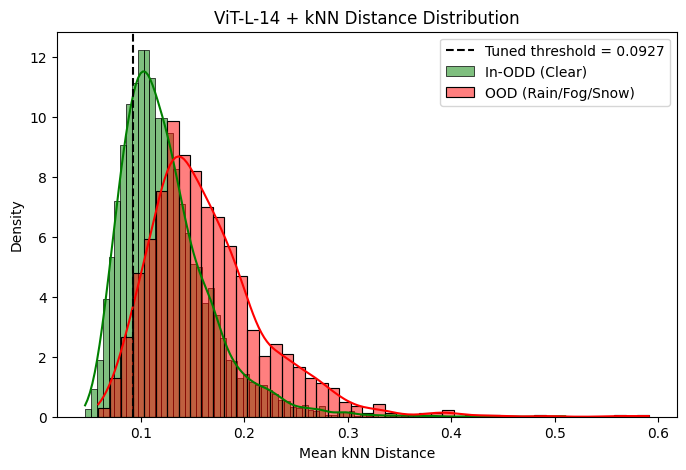

In [10]:
# --- CELL 6: FINAL OOD METRICS AND VISUALIZATION ---

print('Evaluating strongest CLIP + kNN setting on validation data...')
print(f'Backbone     : {CLIP_MODEL_NAME}')
print(f'Selected k   : {BEST_K}')
print(f'kNN AUROC    : {roc_auc_score(val_ood_arr, val_knn_scores):.4f}')
print(f'kNN AUPR     : {average_precision_score(val_ood_arr, val_knn_scores):.4f}')
print(f'kNN FPR95    : {fpr_at_95_tpr(val_ood_arr, val_knn_scores):.4f}')
print('\nTuned kNN threshold:')
print({
    'threshold': KNN_THRESHOLD,
    'false_safe_rate': best_result['false_safe_rate'],
    'coverage': best_result['coverage'],
})

plt.figure(figsize=(8, 5))
sns.histplot(val_knn_scores[val_ood_arr == 0], color='green', label='In-ODD (Clear)', kde=True, stat='density')
sns.histplot(val_knn_scores[val_ood_arr == 1], color='red', label='OOD (Rain/Fog/Snow)', kde=True, stat='density')
plt.axvline(KNN_THRESHOLD, color='black', linestyle='--', label=f'Tuned threshold = {KNN_THRESHOLD:.4f}')
plt.title(f'{CLIP_MODEL_NAME} + kNN Distance Distribution')
plt.xlabel('Mean kNN Distance')
plt.ylabel('Density')
plt.legend()
plt.show()



In [11]:
# --- CELL 7: DEPLOYMENT-STYLE SAFETY GATE ---

def runtime_safety_gate(feature_batch, k=BEST_K, threshold=KNN_THRESHOLD):
    feature_np = feature_batch.cpu().numpy().astype('float32')
    scores = knn_ood_score(feature_np, k=k)
    decisions = []

    for score in scores:
        decision = 'ABSTAIN' if score >= threshold else 'TRUST'
        decisions.append({
            'decision': decision,
            'knn_score': float(score),
        })

    return decisions


print('Deploying strongest CLIP + kNN safety gate...\n')
print('=' * 80)

sample_features = val_features[:10]
sample_ood_labels = val_ood_labels[:10].cpu().numpy()
gate_results = runtime_safety_gate(sample_features)

for i, result in enumerate(gate_results, start=1):
    actual = 'In-ODD' if sample_ood_labels[i - 1] == 0 else 'OOD'
    print(f'Frame {i} [Ground Truth: {actual}]')
    print(f"  -> Decision   : {result['decision']}")
    print(f"  -> kNN Score  : {result['knn_score']:.4f}")
    print('-' * 80)



Deploying strongest CLIP + kNN safety gate...

Frame 1 [Ground Truth: In-ODD]
  -> Decision   : ABSTAIN
  -> kNN Score  : 0.1757
--------------------------------------------------------------------------------
Frame 2 [Ground Truth: In-ODD]
  -> Decision   : ABSTAIN
  -> kNN Score  : 0.1275
--------------------------------------------------------------------------------
Frame 3 [Ground Truth: In-ODD]
  -> Decision   : ABSTAIN
  -> kNN Score  : 0.1184
--------------------------------------------------------------------------------
Frame 4 [Ground Truth: In-ODD]
  -> Decision   : ABSTAIN
  -> kNN Score  : 0.1276
--------------------------------------------------------------------------------
Frame 5 [Ground Truth: In-ODD]
  -> Decision   : ABSTAIN
  -> kNN Score  : 0.1647
--------------------------------------------------------------------------------
Frame 6 [Ground Truth: In-ODD]
  -> Decision   : ABSTAIN
  -> kNN Score  : 0.1182
--------------------------------------------------------